# Hackathon 1, statistics.

This project illustrates the statistics part of the course LEPL1109. In the first part of the project, you will study the mortality observed in Belgium. In the second part of the project, you try to predict the electricity consumption in Belgium using climate variables.

## Report content

•	Grades are granted to the members whose names are in the Jupyter notebook. If your name doesn’t appear on the top of the notebook, you’ll get a 0, even though you are in a group on Moodle.

•	The jupyter notebook must be compiled with printed results and next submitted via moodle. The absence of compiled results (or non-printed values) leads to a lower grade.

•	Do not comment your results directly into cells of code. Use instead a Markdown cell. 

•	"Dry" code or results not followed by a minimum of analysis / comments will be penalized.


## Report submission

•	Deadline, see moodle website. Submission after the deadline will not be accepted.

•	To submit your report, go to the section “Hackathon” on Moodle and the subsection “Remise Hackathon 1”. You can upload your work there. Once you are sure that it is your final version, click the button “Envoyer le devoir”. It is important that you don’t forget to click on this button ! 

•	Reports that have not been uploaded through Moodle will not be corrected.


## Names and Noma of participants:

Part. 1: Mathieu Ledent 75992400

Part. 2: Thibault Vos de Wael 03132401

Part. 3: Valentin Messinne 92992400

Part. 4: Diego Asscherickx 90642300

Part. 5:

Part. 6:

# Mortality and climate

In this section, we analyze the relationship between mortality, age groups, and seasons in Belgium using publicly available data from Statbel (see https://statbel.fgov.be/en/about-statbel/what-we-do/visualisations/mortality). The dataset contains the number of deaths recorded over time, disaggregated by age group and observed across different seasons. The objective is to study temporal patterns in mortality and assess the role of seasonal effects. 

## 1. Basic statistics

**1.1)** Load the dataset mortality_climate.csv. Convert the variables *season* and *CD_AGEGROUP* into a categorical variable. 

In [3]:
import pandas as pd 
import seaborn as sns
import numpy as np 
import scipy.stats as sc 
import matplotlib.pyplot as plt 
data_mortality = pd.read_csv("mortality_climate.csv", sep=',')
data_mortality['date'] = pd.to_datetime(data_mortality['date'])
df_pivot = data_mortality.pivot(index='date', columns='CD_AGEGROUP', values='MS_NUM_DEATH')







**1.2)** Plot the evolution of the number of deaths (*MS_NUM_DEATH*) with respect to age group. What do you observe?

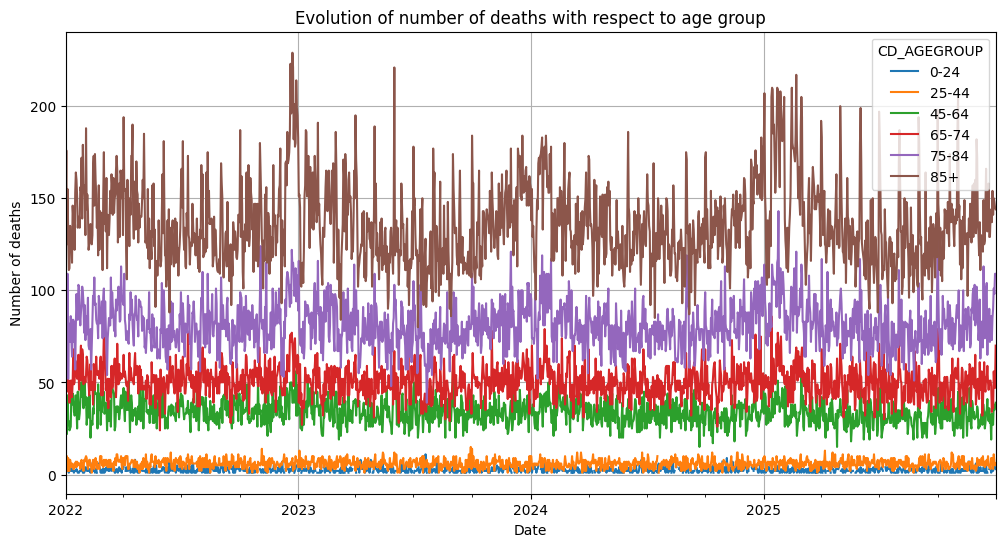

In [4]:
df_pivot.plot(
    figsize=(12, 6),
    xlabel='Date',
    ylabel='Number of deaths',
    title='Evolution of number of deaths with respect to age group',
    grid=True
)

plt.show()


comment:
On observe que le groupe des 0-24 ans et celui des 25-44 ans sont presque superposé. En suite le nombre de mort augmente de manière croissante en fonction de l'age des groupes. Sur une année pour chaque groupe. On a une sorte de sinusoide qui atteint son max en début d'année donc pendant l'hiver et son min en milieu d'année vers le printemps. 

**1.3)** Do a scatter plot of the number of deaths (*MS_NUM_DEATH*) by age group.

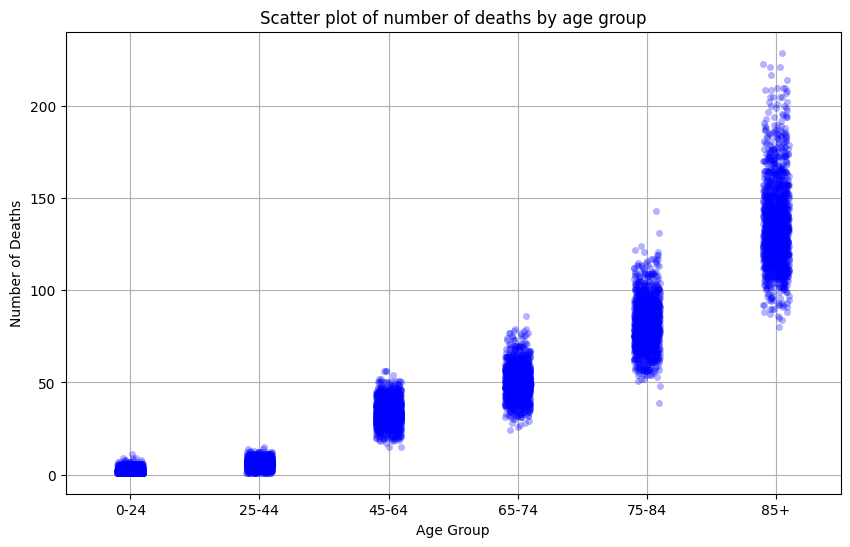

In [5]:
ordre_ages = ['0-24', '25-44', '45-64', '65-74', '75-84', '85+']
data_mortality['CD_AGEGROUP'] = pd.Categorical(data_mortality['CD_AGEGROUP'], categories=ordre_ages, ordered=True)

plt.figure(figsize=(10, 6))
sns.stripplot(
    data=data_mortality,
    x='CD_AGEGROUP',
    y='MS_NUM_DEATH',
    alpha=0.3,       
    color='blue',    
    jitter=True      
)

plt.title('Scatter plot of number of deaths by age group')
plt.xlabel('Age Group')
plt.ylabel('Number of Deaths')
plt.grid(True)

plt.show()


Comment : 
Le graphique montre que le nombre quotidien de décès chez les 0-24 ans et les 25-44 ans est très faible en comparaison avec les autres tranches d'âge. De plus, l'étendue verticale (qui représente la variance ou la dispersion des données) est de plus en plus grande à mesure que l'âge des groupes augmente

## 2. Fit of distributions

**2.1)** For the 45–64 age group and the winter season only, fit both a Poisson and a Negative Binomial distribution to the variable 'MS_NUM_DEATH' using a maximum likelihood approach. Plot histograms overlaid with the fitted probability mass functions. Compare the log-likelihoods and select the most appropriate distribution.

Moyenne: 35.43490304709141
Variance: 48.7297783933518
lambda_hat :  35.43490304709141
log_likelihood_poisson :  -1220.892273349366


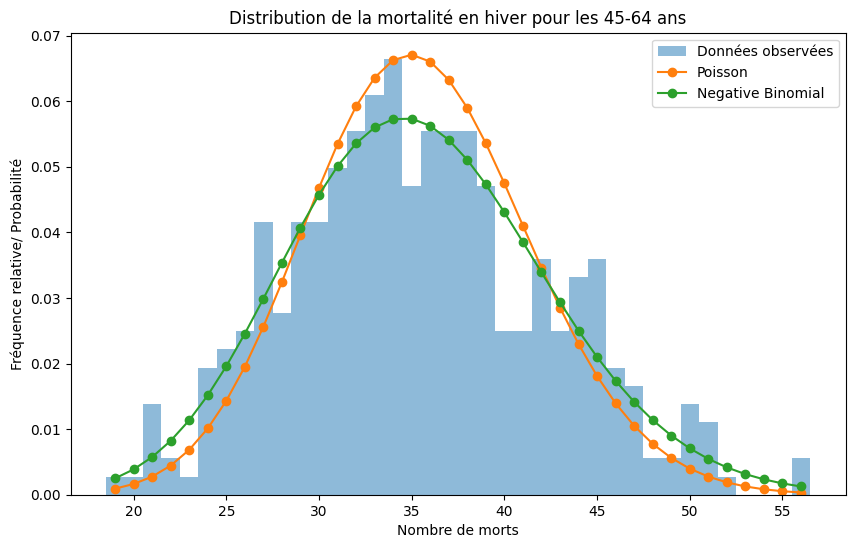

In [6]:
from scipy.optimize import minimize

winter_mask = df_pivot.index.month.isin([12, 1, 2])
winter_45_64 = df_pivot.loc[winter_mask, '45-64'].dropna()

x = winter_45_64.to_numpy()

print("Moyenne:", x.mean())
print("Variance:", x.var(ddof=1))

#Par Maximum Likelihood:

lambda_hat = x.mean()
print("lambda_hat : ", lambda_hat)

log_likelihood_poisson = np.sum(sc.poisson.logpmf(winter_45_64, mu=lambda_hat))
print("log_likelihood_poisson : ", log_likelihood_poisson)

# Negative Binomial :

mean_x = x.mean()
var_x = x.var(ddof=1)

# Initial estimates
p0 = mean_x / var_x
n0 = mean_x**2 / (var_x - mean_x)

def neg_log_likelihood_nb(params):
    n, p = params
    return -np.sum(sc.nbinom.logpmf(x, n, p))

result = minimize(
    neg_log_likelihood_nb,
    x0=[n0, p0],
    bounds=[
        (1e-6, None),
        (1e-6, 1 - 1e-6)
    ]
)

n_hat, p_hat = result.x
log_likelihood_nb = -result.fun

k = np.arange(int(x.min()), int(x.max()) + 1)

poisson_fit = sc.poisson.pmf(k, lambda_hat)
nb_fit = sc.nbinom.pmf(k, n_hat, p_hat)

plt.figure(figsize=(10, 6))

plt.hist(
    x,
    bins=np.arange(x.min() - 0.5, x.max() + 1.5),
    density=True,
    alpha=0.5,
    label='Données observées'
)

plt.plot(k, poisson_fit, 'o-', label='Poisson')
plt.plot(k, nb_fit, 'o-', label='Negative Binomial')

plt.xlabel('Nombre de morts')
plt.ylabel('Fréquence relative/ Probabilité')
plt.title('Distribution de la mortalité en hiver pour les 45-64 ans')
plt.legend()

plt.show()

Comments:
Note :
La loi de Poisson suppose que la moyenne et la variance soient égales. Or, dans notre cas, la variance est supérieure à la moyenne, ce qui indique une surdispersion des données. Cela suggère que la loi binomiale négative est probablement plus adaptée.

Interprétation du graphe :
Nous remarquons que la distribution est centrée autour de 35 décès ainsi qu'une dispersion s'étendant de 20 à 55 ans. On observe que la loi de Poisson est davantage concentrée autour de la moyenne, tandis que la loi binomiale négative est plus étalée. Cette dernière semble donc mieux représenter la variabilité présente dans les données, ce qui est cohérent avec la surdispersion observée.


# 3. Regression

We now aim to assess whether seasonality has an impact on the number of deaths. We consider the following linear model:
$$\log(Y_i) = \beta_0 + \beta_1 X^S_{i1} + \cdots + \beta_3 X^S_{i3} + \beta_4 X^{age}_{i1} + \cdots + \beta_8 X^{age}_{i5}  + \varepsilon_i.$$

where $Y_i$ denotes the number of deaths, $X^S_{ij}$ are dummy variables representing the different seasons, $X^{age}_{ij}$ are dummy variables representing the different age groups, and $\varepsilon_i \sim N(0, \sigma^2)$. 

**3.1)** Why is it more appropriate to use a linear regression on $\log(Y)$ rather than directly on $Y$?

Comments:

Poser a echelle logarithmique la variables de décès Y est important pour deux motives :
- Obtenir des prédictions positives par rapport aux nombres de décès, effectivement cette combinaison pourrait mener a une quantité négative ce qui ne serrait pas des résultats réels. Donc on aura Y = exp(X*betta).

- Comme dit au point précédant nous avons Y = exp(X*betta), donc afin de convertir un effet multiplicatif en une experession lineaire additive, nous utilisons donc log(Y) pour la regression lineaire.

**3.2)** Perform a linear regression of the number of deaths on the seasonal and group age covariates. Use the `OLS` function from the *statsmodels* package. Make sure to convert the variable *season* and *CD_AGEGROUP* into dummy variables before fitting the model.

Does seasonality have a significant impact on mortality? Is the mortality similar for each age group? 

In [7]:
# Code here
import statsmodels.api as sm
import pandas as pd
import numpy as np

#Conversion des variables 'season' et 'CD_AGEGROUPE' en variables indicatrice, c'est à dire, 0 ou 1.
dum_variables = pd.get_dummies(data_mortality, columns=['season', 'CD_AGEGROUP'], drop_first=True, dtype=int)

#Préparation des variables avant la régression linéaire.
Y = np.log(data_mortality['MS_NUM_DEATH'])
X = dum_variables.drop(columns=['date', 'MS_NUM_DEATH'])

#Ajout de la constante betta0.
X = sm.add_constant(X)

#Construction de la régression linéaire
model = sm.OLS(Y, X)

#Calcul du terme d'erreur epsilon(i).
results = model.fit()

#Affichage du tableau des résultats statistiques.
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           MS_NUM_DEATH   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                 2.110e+04
Date:                Sat, 10 Oct 2026   Prob (F-statistic):               0.00
Time:                        09:08:31   Log-Likelihood:                -2628.0
No. Observations:                8625   AIC:                             5274.
Df Residuals:                    8616   BIC:                             5338.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7921      0.01

Comments: 

On observe qu'on a comme référence de saison, l'automne et de groupe d'ages, 0-24. 
Pour savoir si les nombres des décès est significatives par rapport a la saison de l'automne ou aux groupes d'ages 0-24 nous fixons un seuil de 0.05 :
- Printemps : 0.262 > 0.05, donc pas d'impact significatif.
- Hiver : 0.003 < 0.05, impact significatif avec augmentation de la mortalité car coef positive.
- Eté : 0.000 < 0.05, impact significatif avec diminution de la mortalité car coef négative.

Pour le groupe d'ages on observe que tous leurs p-value est de 0 donc plus petis que le seuil 0.05, ce qui implique un impact significatif avec augmentation de décès pour tout groupe par rapport au groupe d'age 0-24.

## 4. Hypothesis test 

We now investigate whether mortality decreases over time by comparing mortality in summer in 2022 and 2025. To this end, we aim to perform the following hypothesis test:

$$
H_0 : \mu_{2022} = \mu_{2025},
$$

$$
H_1 : \mu_{2022} \neq \mu_{2025}.
$$

**4.1)** Create two subsets of the original dataset corresponding to the years 2022 and 2025, respectively.

In [8]:
# Code here
subset_22 = df_pivot.loc[(df_pivot.index >= "01.01.2022") & (df_pivot.index <= "31.12.2022")]
subset_25 = df_pivot.loc[(df_pivot.index >= "01.01.2025") & (df_pivot.index <= "31.12.2025")]

**4.2)** For the 85+ age group, perform a Student’s t-test to compare mortality between 2022 and 2025 **in summer**. Check whether the assumptions required to apply this test are satisfied.

In [ ]:
# Code here


Comments:

**4.3)** Explain what the Wilcoxon test is. Why could it be relevant in our setting?

Comments: 

**4.4)** For the 85+ age group, perform a Wilcoxon test to compare mortality between 2022 and 2025 **in summer**. What do you conclude?

In [ ]:
# Code here


Comments:

**4.5)** Perform the Wilcoxon test but now for the 25–44 age group and the **summer**. What do you conclude in this case?

In [ ]:
# Code here 


Comments: 

# Electricity Consumption and Climate

In this section, we aim to predict electricity consumption using past consumption values and climatic variables. We rely on data provided by ELIA (see https://opendata.elia.be/explore/dataset/ods003/information/?sort=datetime), which records total electricity consumption in Belgium at a 15-minute frequency, and meteorological data from the Royal Meteorological Institute (IRM) (see https://www.meteo.be/fr/services/donnees), which provides daily average temperature observations over Belgium.

The goal is to build a predictive model for electricity demand based on its recent history and weather conditions. From a practical perspective, such forecasting is highly relevant for energy providers and grid operators, as accurately anticipating electricity demand one week ahead helps optimize production planning, ensure grid stability, and reduce operational costs.

## 5. Forecasting 

The goal is to predict electricity consumption at time $t$ using its past values and climate features. Let $Y_t$ denote electricity consumption at time $t$. We consider the following regression model:

$$Y_t = \beta_0 + \beta_1 Y_{t-7Days} + \beta_2 \bar{T}_{t-7Days} + \beta_3 \bar{T}_{t-7Days}^2 + \varepsilon_t,$$

where $Y_{t-7Days}$ denotes electricity consumption observed 7 days earlier, $\bar{T}_{t-7Days}$ is the average temperature observed 7 days earlier$^1$, and $\varepsilon_t \sim \mathcal{N}(0,\sigma^2)$ is an error term.

$^1$ The average temperature is measured at a daily frequency; therefore, $\bar{T}_{t-7Days}$ is constant for all time points $t$ within the same day.

**5.1)** Load the dataset *electricity_climate.csv* and construct the dataset required to perform the regression.

**Warning:** the data are observed at 15-minute intervals.

To build the regression dataset, each row must contain:
- electricity consumption at time $t$: $Y_t$,
- electricity consumption at time $t - 7$ days: $Y_{t-7Days}$,
- temperature at time $t - 7$ days: $\bar{T}_{t-7Days}$,
- the squared temperature at time $t - 7$ days: $\bar{T}_{t-7Days}^2$.

In [ ]:
# Code here 


**5.2)** Split the dataset into a training set (first 75%) and a test set (last 25%).  Use the `OLS` function from the *statsmodels* package to fit linear regression model using only $Y_{t-7Days}$ as explanatory variable.

Analyze the regression output, discuss the statistical significance and performance of the model.

In [ ]:
# Code here 


Comments:

**5.3)** Repeat the regression by including the climate variables in the model.

Are the climate variables statistically significant in explaining electricity consumption 7 days ahead?

In [ ]:
# Code here


Comments: 

**5.4)** Compute the MAE and RMSE on the test set for both models: with and without climate variables.

Does the inclusion of climate variables improve the predictive performance of the model?

In [ ]:
# Code here 


Comments: 

**5.5)** For the model including climate variables, plot the predicted electricity consumption versus the true consumption on the test set. Then, produce a second plot focusing only on the first 7 days of the test set.

In [ ]:
# Code here 


Comments: